🚗 Vehicle Sensor Anomaly Detection

Objective:
Detect abnormal sensor values over time.

Approach:
Time-series analysis
Statistical thresholding

Result:
Successfully identified anomalies in sensor data

In [26]:
import pandas as pd

url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/ambient_temperature_system_failure.csv"
df = pd.read_csv(url)

df.head()

,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551


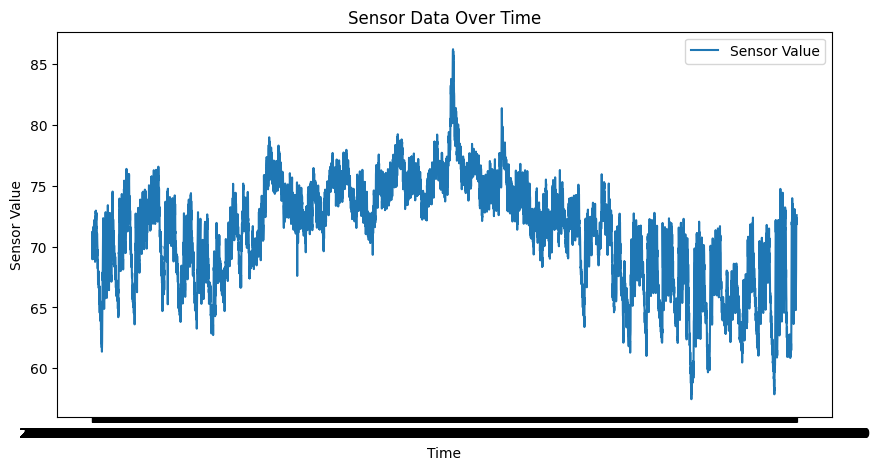

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['timestamp'], df['value'], label='Sensor Value')

plt.legend()
plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.title("Sensor Data Over Time")

plt.show()

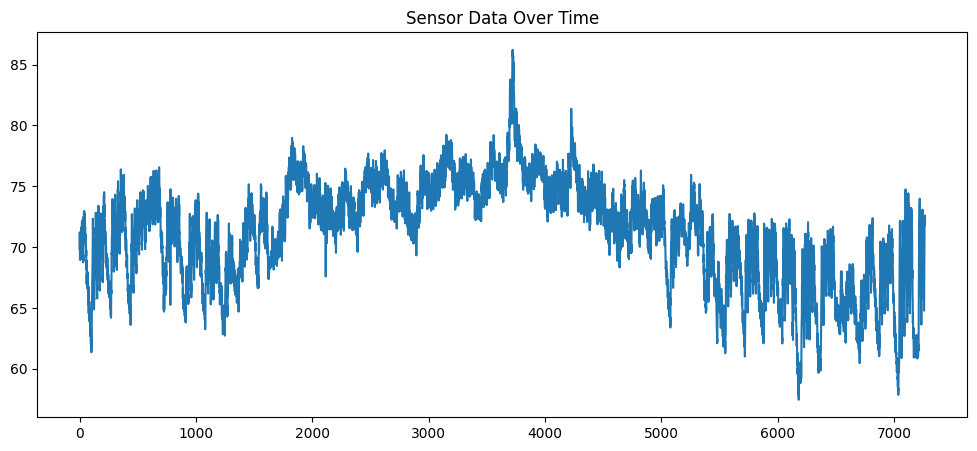

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['value'])
plt.title("Sensor Data Over Time")
plt.show()

In [29]:
mean = df['value'].mean()
std = df['value'].std()

threshold_upper = mean + 2*std
threshold_lower = mean - 2*std

df['anomaly'] = ((df['value'] > threshold_upper) | (df['value'] < threshold_lower)).astype(int)

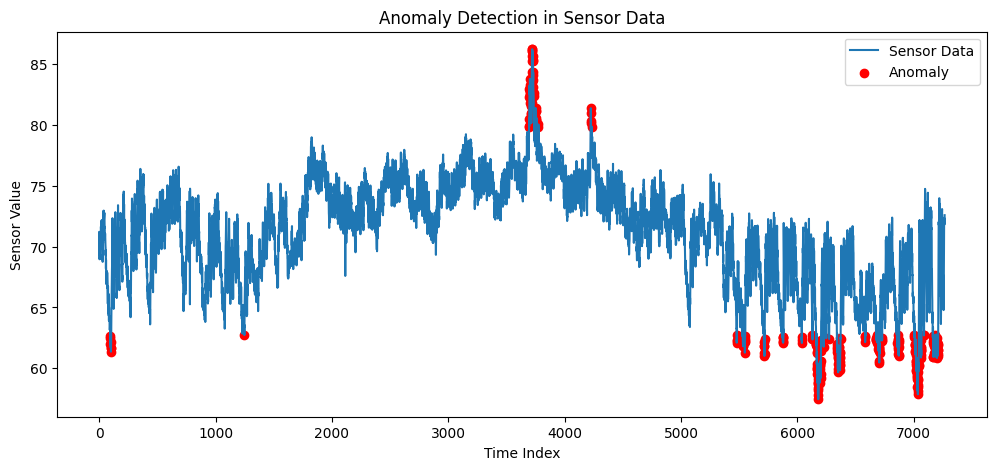

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Plot full sensor data
plt.plot(df['value'], label='Sensor Data')

# Highlight anomalies
plt.scatter(
    df[df['anomaly']==1].index,
    df[df['anomaly']==1]['value'],
    color='red',
    label='Anomaly'
)

# Labels
plt.title("Anomaly Detection in Sensor Data")
plt.xlabel("Time Index")
plt.ylabel("Sensor Value")

# Legend
plt.legend()

plt.show()

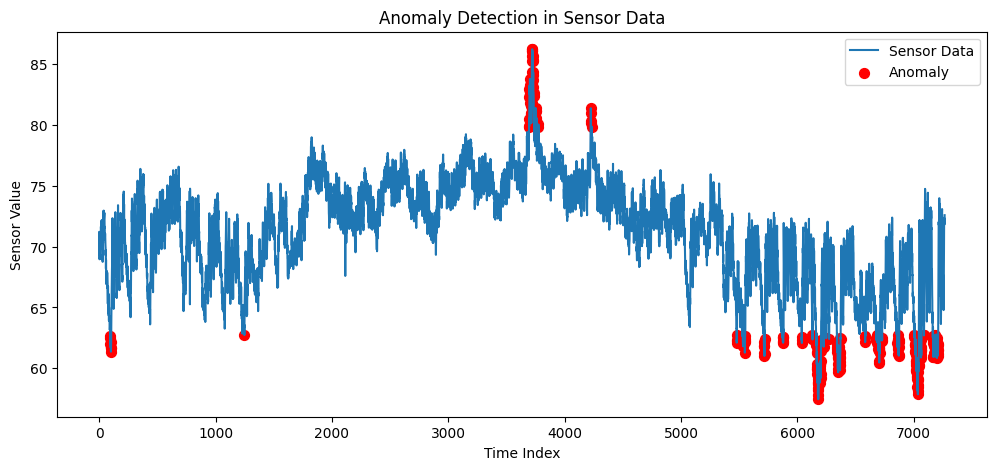

In [31]:
plt.figure(figsize=(12,5))
plt.plot(df['value'], label='Sensor Data')
plt.scatter(df[df['anomaly']==1].index, df[df['anomaly']==1]['value'], color='red', s=50,  label='Anomaly')

plt.title("Anomaly Detection in Sensor Data")
plt.xlabel("Time Index")
plt.ylabel("Sensor Value")
plt.legend()
plt.show()